In [1]:
# Install the libraries you need
#! pip install lightgbm

In [2]:
#! pip install shap

In [3]:
# Import all the libraries you'll be using

import pandas as pd
import numpy as np
import math
import seaborn as sns
import matplotlib as plt
from datetime import date
import datetime
from sklearn import metrics
from sklearn.model_selection import StratifiedShuffleSplit
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV
import boto3
import datetime
from sklearn.model_selection import train_test_split
import shap


%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## Data Collection

In [4]:
# Load dataset provided from Kaggle
# We merge the the training and test dataset for now, as we'll run QA and transformations on all the data

df_train = pd.read_csv('aug_train.csv')
df_test = pd.read_csv('aug_test.csv')
df = pd.concat([df_train, df_test])

In [5]:
# Size of the data
df.shape

(21287, 14)

In [6]:
# Checkout the features
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


## Data Exploration

In [7]:
df.shape

(21287, 14)

In [8]:
# Unique on enrollee id
df['enrollee_id'].nunique() == df.shape[0]

True

In [9]:
# Any person duplicates?
df['duplicated'] = df.drop(columns = ['enrollee_id']).duplicated()

In [10]:
df['duplicated'].value_counts()

duplicated
False    21237
True        50
Name: count, dtype: int64

In [11]:
df.drop(df[df['duplicated'] == True].index, inplace = True)
df.head(2)
print(f'New df size is {df.shape}')

New df size is (21235, 15)


In [12]:
# Descriptive stats
df.describe()

,enrollee_id,city_development_index,training_hours,target
count,21235.000000,21235.000000,21235.000000,19108.000000
mean,16871.884624,0.828312,65.397174,0.249372
std,9610.508821,0.123575,60.114693,0.432661
min,1.000000,0.448000,1.000000,0.000000
25%,8558.500000,0.739000,23.000000,0.000000
50%,16958.000000,0.903000,47.000000,0.000000
75%,25158.500000,0.920000,88.000000,0.000000
max,33380.000000,0.949000,336.000000,1.000000


In [13]:
# Check unique and null counts, does everything look as expected?
for col in df.columns:
    print(f' \n {col.upper()} contains {df[col].nunique()} unique values and {df[col].isnull().sum()} nulls')

 
 ENROLLEE_ID contains 21235 unique values and 0 nulls
 
 CITY contains 123 unique values and 0 nulls
 
 CITY_DEVELOPMENT_INDEX contains 93 unique values and 0 nulls
 
 GENDER contains 3 unique values and 5015 nulls
 
 RELEVENT_EXPERIENCE contains 2 unique values and 0 nulls
 
 ENROLLED_UNIVERSITY contains 3 unique values and 417 nulls
 
 EDUCATION_LEVEL contains 5 unique values and 512 nulls
 
 MAJOR_DISCIPLINE contains 6 unique values and 3121 nulls
 
 EXPERIENCE contains 22 unique values and 70 nulls
 
 COMPANY_SIZE contains 8 unique values and 6541 nulls
 
 COMPANY_TYPE contains 6 unique values and 6755 nulls
 
 LAST_NEW_JOB contains 6 unique values and 463 nulls
 
 TRAINING_HOURS contains 241 unique values and 0 nulls
 
 TARGET contains 2 unique values and 2127 nulls
 
 DUPLICATED contains 1 unique values and 0 nulls


In [14]:
# Drop unlabeled target rows
df.dropna(subset=['target'], how='all', inplace=True)

In [15]:
print(df.shape[0])

df['target'].value_counts()

19108


target
0.0    14343
1.0     4765
Name: count, dtype: int64

In [16]:
df['company_size'].value_counts()

company_size
50-99        3080
100-500      2560
10000+       2009
10/49        1470
1000-4999    1322
<10          1308
500-999       877
5000-9999     562
Name: count, dtype: int64

In [17]:
# Tidy up 10/49 to 10-49
df['company_size'] = df['company_size'].apply(lambda x: '10-49' if x == '10/49' else x)

In [18]:
df['company_size'].value_counts()

company_size
50-99        3080
100-500      2560
10000+       2009
10-49        1470
1000-4999    1322
<10          1308
500-999       877
5000-9999     562
Name: count, dtype: int64

<Axes: >

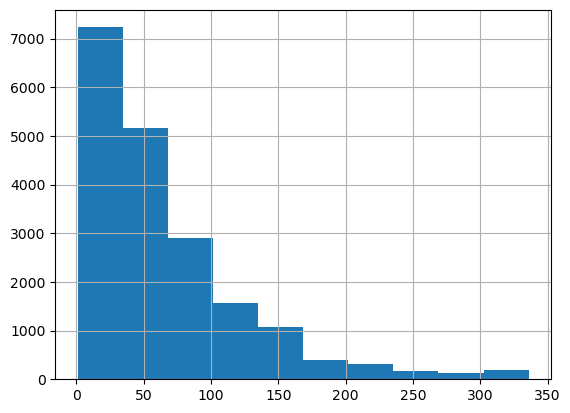

In [19]:
# Training hours distribution
df['training_hours'].hist()

<Axes: xlabel='education_level', ylabel='training_hours'>

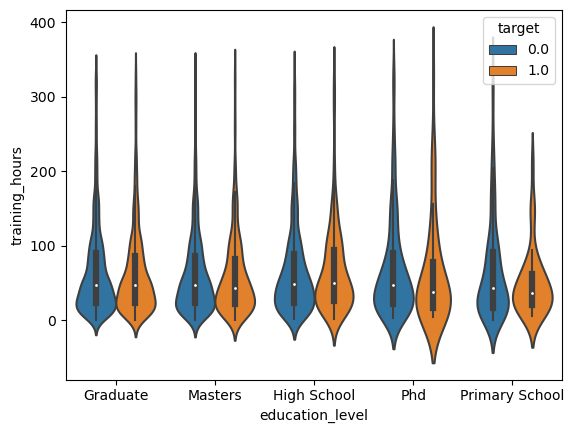

In [20]:
# Seaborn example
sns.violinplot(data=df, x="education_level", y="training_hours", hue="target", gridsize = 200)

## Feature Engineering

In [21]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,duplicated
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0,False
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0,False
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0,False
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0,False
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0,False


In [22]:
# Are classes balanced?
df['target'].value_counts()

target
0.0    14343
1.0     4765
Name: count, dtype: int64

In [23]:
# Total number of nulls in dataset
df.isnull().sum()

enrollee_id                  0
city                         0
city_development_index       0
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2809
experience                  65
company_size              5920
company_type              6122
last_new_job               423
training_hours               0
target                       0
duplicated                   0
dtype: int64

In [24]:
#

## Data Transformation

In [25]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,duplicated
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0,False
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0,False
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0,False
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0,False
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0,False


In [26]:
# Drop columns we don't want to pass to model
df_model = df.drop(['duplicated', 'enrollee_id'], axis=1)

In [27]:
# Any categorical columns require numeric indicator variables (i.e. pandas dummies)
# Craig
cat_cols = []

for col in df_model.columns:
    print('\n')
    print(f'Column {col} is of data type {df_model[col].dtype}')   
    if df_model[col].dtype == 'object':
        print('Creating dummies for it')
        cat_cols.append(col)
df_model = pd.get_dummies(df_model, columns=cat_cols, dtype=int)



Column city is of data type object
Creating dummies for it


Column city_development_index is of data type float64


Column gender is of data type object
Creating dummies for it


Column relevent_experience is of data type object
Creating dummies for it


Column enrolled_university is of data type object
Creating dummies for it


Column education_level is of data type object
Creating dummies for it


Column major_discipline is of data type object
Creating dummies for it


Column experience is of data type object
Creating dummies for it


Column company_size is of data type object
Creating dummies for it


Column company_type is of data type object
Creating dummies for it


Column last_new_job is of data type object
Creating dummies for it


Column training_hours is of data type int64


Column target is of data type float64


In [28]:
# Target col should be int 0 or 1
df_model['target'] = pd.to_numeric(df_model['target'])
df_model['target'] = df_model['target'].astype(int)

In [29]:
df_model['target'].value_counts()

target
0    14343
1     4765
Name: count, dtype: int64

In [30]:
# Ensure dummies look good
df_model.head()

,city_development_index,training_hours,target,city_city_1,city_city_10,city_city_100,city_city_101,city_city_102,city_city_103,city_city_104,city_city_105,city_city_106,city_city_107,city_city_109,city_city_11,city_city_111,city_city_114,city_city_115,city_city_116,city_city_117,city_city_118,city_city_12,city_city_120,city_city_121,city_city_123,city_city_126,city_city_127,city_city_128,city_city_129,city_city_13,city_city_131,city_city_133,city_city_134,city_city_136,city_city_138,city_city_139,city_city_14,city_city_140,city_city_141,city_city_142,city_city_143,city_city_144,city_city_145,city_city_146,city_city_149,city_city_150,city_city_152,city_city_155,city_city_157,city_city_158,city_city_159,city_city_16,city_city_160,city_city_162,city_city_165,city_city_166,city_city_167,city_city_171,city_city_173,city_city_175,city_city_176,city_city_179,city_city_18,city_city_180,city_city_19,city_city_2,city_city_20,city_city_21,city_city_23,city_city_24,city_city_25,city_city_26,city_city_27,city_city_28,city_city_30,city_city_31,city_city_33,city_city_36,city_city_37,city_city_39,city_city_40,city_city_41,city_city_42,city_city_43,city_city_44,city_city_45,city_city_46,city_city_48,city_city_50,city_city_53,city_city_54,city_city_55,city_city_57,city_city_59,city_city_61,city_city_62,city_city_64,city_city_65,city_city_67,city_city_69,city_city_7,city_city_70,city_city_71,city_city_72,city_city_73,city_city_74,city_city_75,city_city_76,city_city_77,city_city_78,city_city_79,city_city_8,city_city_80,city_city_81,city_city_82,city_city_83,city_city_84,city_city_89,city_city_9,city_city_90,city_city_91,city_city_93,city_city_94,city_city_97,city_city_98,city_city_99,gender_Female,gender_Male,gender_Other,relevent_experience_Has relevent experience,relevent_experience_No relevent experience,enrolled_university_Full time course,enrolled_university_Part time course,enrolled_university_no_enrollment,education_level_Graduate,education_level_High School,education_level_Masters,education_level_Phd,education_level_Primary School,major_discipline_Arts,major_discipline_Business Degree,major_discipline_Humanities,major_discipline_No Major,major_discipline_Other,major_discipline_STEM,experience_1,experience_10,experience_11,experience_12,experience_13,experience_14,experience_15,experience_16,experience_17,experience_18,experience_19,experience_2,experience_20,experience_3,experience_4,experience_5,experience_6,experience_7,experience_8,experience_9,experience_<1,experience_>20,company_size_10-49,company_size_100-500,company_size_1000-4999,company_size_10000+,company_size_50-99,company_size_500-999,company_size_5000-9999,company_size_<10,company_type_Early Stage Startup,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,last_new_job_1,last_new_job_2,last_new_job_3,last_new_job_4,last_new_job_>4,last_new_job_never
0,0.920,36,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1,0.776,47,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0
2,0.624,83,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0

In [31]:
# See what features are most correlated to the dependent variable
# How should we interpret this?
def gen_corr_grid(df, depvar):
    corr_dict = {
            'variable': [],
            'corr': []
        }
    for col in list(df.columns):
        if df[col].dtype not in ['object', '<M8[ns]'] and col != depvar :
            r = df[depvar].corr(df[col])   
            corr_dict['variable'].append(col)
            corr_dict['corr'].append(r)
    return pd.DataFrame(corr_dict).sort_values(by=['corr'], ascending=False)


df_corrs = gen_corr_grid(df_model, 'target')
df_corrs.head(20)

,variable,corr
66,city_city_21,0.319434
130,enrolled_university_Full time course,0.149529
129,relevent_experience_No relevent experience,0.127994
13,city_city_11,0.091457
133,education_level_Graduate,0.087214
164,experience_<1,0.079047
144,experience_1,0.069583
157,experience_3,0.066304
26,city_city_128,0.050778
143,major_discipline_STEM,0.050013


### Create training and test data to pass to the model

In [32]:
# 80/20 split
train, test = train_test_split(df_model, test_size=0.2)

# Breakout identifies the feature cols so we break out our x (features) and y (target col) values in next cell
breakout = list(set(train.columns) - set(['target']))

In [33]:
def split_x_y(test_in, train_in, breakout, depvar):
    train = train_in.copy()
    test = test_in.copy()

    X_train = train[breakout].copy()
    X_test = test[breakout].copy()
    
    y_train = train[depvar]
    y_test = test[depvar]
        
    X_columns = X_train.columns
        
    return X_train, X_test, y_train, y_test, X_columns

In [34]:
X_train, X_test, y_train, y_test, X_columns = split_x_y(test, train, breakout, 'target')

In [35]:
# Confirm 80/20 split
print(X_train.shape)
print(y_train.shape)

(15286, 186)
(15286,)


In [36]:
print(X_test.shape)
print(y_test.shape)

(3822, 186)
(3822,)


In [37]:
X_test.dtypes

city_city_37                                     int32
city_city_26                                     int32
education_level_Graduate                         int32
city_city_155                                    int32
city_city_173                                    int32
city_city_91                                     int32
city_city_24                                     int32
city_city_23                                     int32
city_city_142                                    int32
city_city_65                                     int32
city_city_131                                    int32
city_city_69                                     int32
city_city_11                                     int32
city_city_46                                     int32
city_city_101                                    int32
city_city_116                                    int32
city_city_53                                     int32
city_city_152                                    int32
company_si

## Model Training

In [38]:
# Generate 5 splits
cv_sss = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=77)

In [39]:
# Train the model
def fit_lgb(param_grid, X, y, cv):
    
    gbm = lgb.LGBMClassifier(objective='binary',
                            feature_fraction= 0.9)
    
    grid_search = GridSearchCV(gbm, 
                               param_grid=param_grid,
                               scoring='roc_auc',
                               cv=cv,
                               verbose=1,
                              n_jobs=-1)   
    
    grid_search.fit(X=X, y=y.values.ravel())
    
    print(grid_search.best_score_)
    print(grid_search.best_estimator_)
    print(grid_search.best_params_)
    return grid_search

In [40]:
# You can test out other hyperparameter values to see if it improves performance
param_grid = { 'learning_rate': [0.05],
                'n_estimators': [400],
                'max_depth': [5, 7],
                'min_child_samples': [50, 200, 600],
                'num_leaves': [31, 63] }

grid_search = fit_lgb(param_grid, X_train, y_train, cv_sss)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Info] Number of positive: 3851, number of negative: 11435
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002758 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 473
[LightGBM] [Info] Numb

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

LGBMClassifier(feature_fraction=0.9, learning_rate=0.05, max_depth=5,
               min_child_samples=200, n_estimators=400, objective='binary')
{'learning_rate': 0.05, 'max_depth': 5, 'min_child_samples': 200, 'n_estimators': 400, 'num_leaves': 31}


## Evaluation

In [41]:
# Pass test data to our trained model. 
y_pred = grid_search.best_estimator_.predict_proba(X_test)[:,1]
auc = metrics.roc_auc_score(y_true=y_test, y_score=y_pred)
print(auc)

fi = pd.Series(grid_search.best_estimator_.feature_importances_, index=X_columns).sort_values(ascending=False)
fi

[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
0.7948084812439238


training_hours                                 1344
city_development_index                          837
company_type_Pvt Ltd                            302
last_new_job_1                                  161
education_level_Graduate                        150
relevent_experience_Has relevent experience     134
gender_Male                                     128
company_size_50-99                              126
company_size_100-500                            106
enrolled_university_no_enrollment                98
company_size_10-49                               84
company_size_1000-4999                           83
company_size_10000+                              82
major_discipline_STEM                            78
city_city_103                                    70
company_size_<10                                 70
enrolled_university_Full time course             66
last_new_job_never                               62
education_level_Masters                          60
company_size

## Explainability

In [42]:
# X_test.head()
# X_test = X_test.to_numpy()

In [43]:
# Using SHAP values
# Fit the explainer
explainer = shap.Explainer(grid_search.best_estimator_.predict, X_test)
# Calculates the SHAP values - this takes some time
shap_values = explainer(X_test)

[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (

[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (

PermutationExplainer explainer:   1%|▎                                                       | 20/3822 [00:00<?, ?it/s]

[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).


PermutationExplainer explainer:   1%|▎                                               | 22/3822 [00:10<07:36,  8.33it/s]

...

[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (

PermutationExplainer explainer: 100%|██████████████████████████████████████████████| 3822/3822 [16:39<00:00,  4.15it/s]

[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).


PermutationExplainer explainer: 3823it [16:40,  3.80it/s]                                                              

[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).


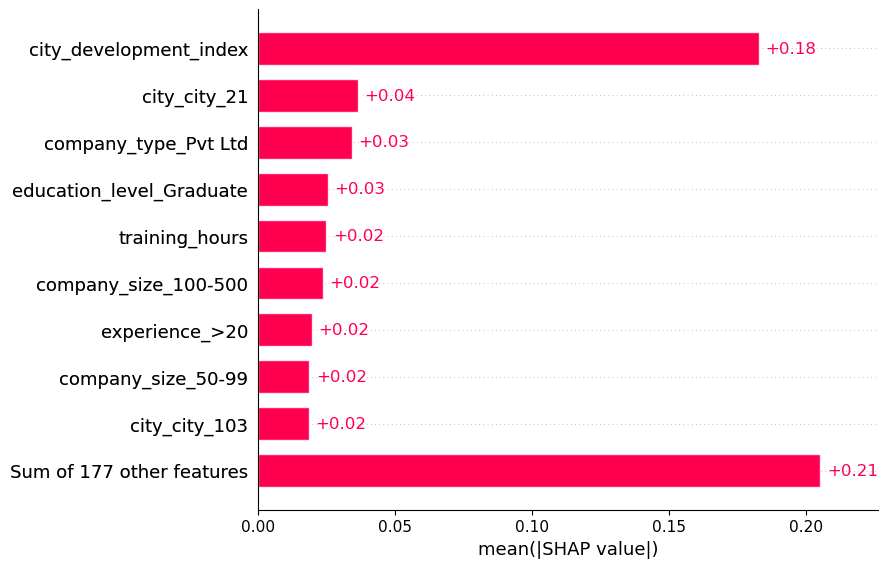

In [44]:
# Features ordered from highest to lowest impact on prediction
shap.plots.bar(shap_values)

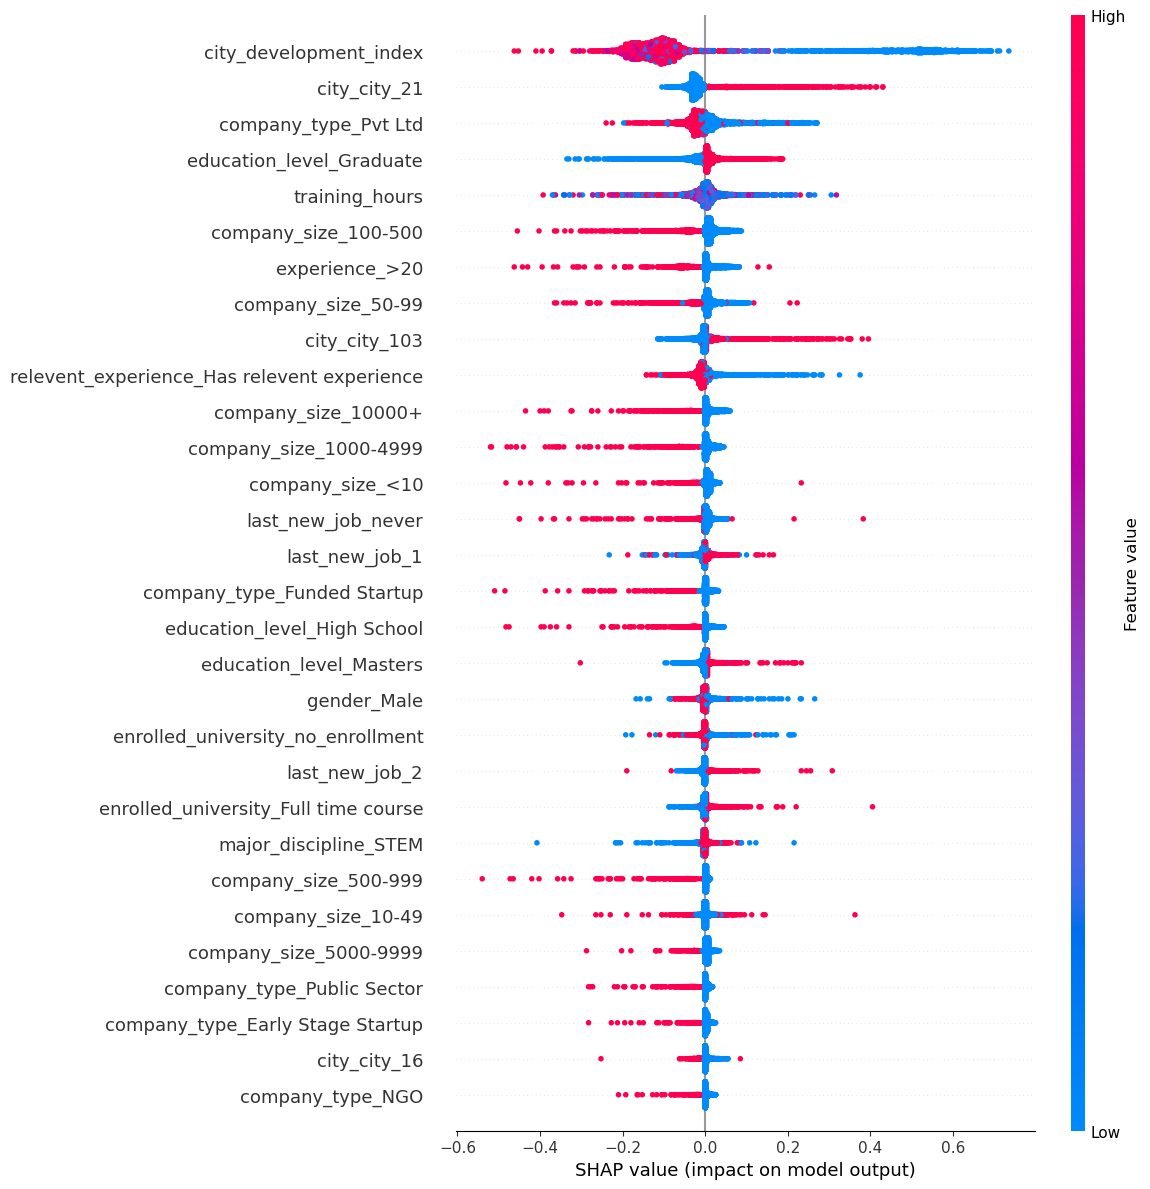

In [45]:
# How do higher/lower values of each feature affect the prediction?
shap.summary_plot(shap_values, plot_size = (12,12), max_display = 30)